# **CREDIT CARD FRAUD PREDICTION**

## **EDA on Credit Card Fraud Detection Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv ('/content/creditcard.csv')
df.head ()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## **Context**

The dataset contains transactions made by credit cards in September 2013 by European cardholders.

Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'.

In [ ]:
df.shape

(284807, 31)

In [ ]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## **Initial Statistical Information**

In [ ]:
df.describe ()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## **Finding null values if any**

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


## **Checking for Duplicates**

In [ ]:

df.duplicated().sum()

np.int64(1081)

## **1081 records are duplicated**
Let's drop them

In [ ]:
df1 = df.drop_duplicates()
df1.shape

(283726, 31)

In [ ]:
counts = len(df) - len(df1)
counts

1081

The target variable 'Class' represents whether a transaction is fraudulent (1) or normal (0).

In [ ]:
df1['Class'].value_counts()

,count
Class,
0,283253
1,473


We see that the number of fraudulent transactions '1' and non-fraudulent transactions '0' are highly imbalanced

## **Showing the imbalance as bar plot**

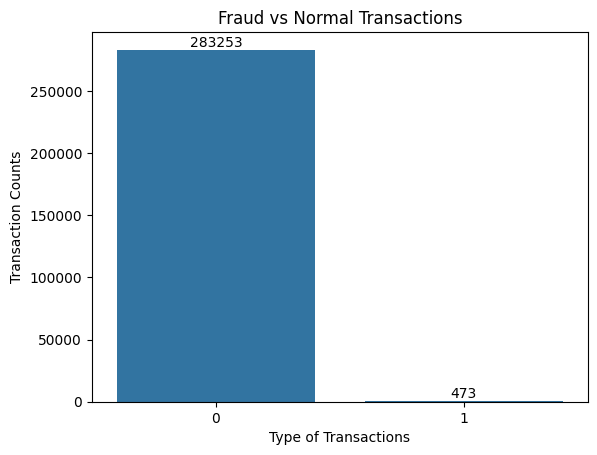

In [ ]:
import seaborn as sns

class_counts = df1['Class'].value_counts()

ax = sns.barplot(x=class_counts.index, y=class_counts.values)

ax.bar_label(ax.containers[0])

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Type of Transactions")
plt.ylabel("Transaction Counts")

plt.show()

The data is extremely lopsided. Because legitimate transactions happen millions of times more often than scams, the fraud cases are buried. This makes it hard for a computer to learn what a 'fraud' pattern actually looks like when it almost never sees one.

## **Transaction amount distribution**

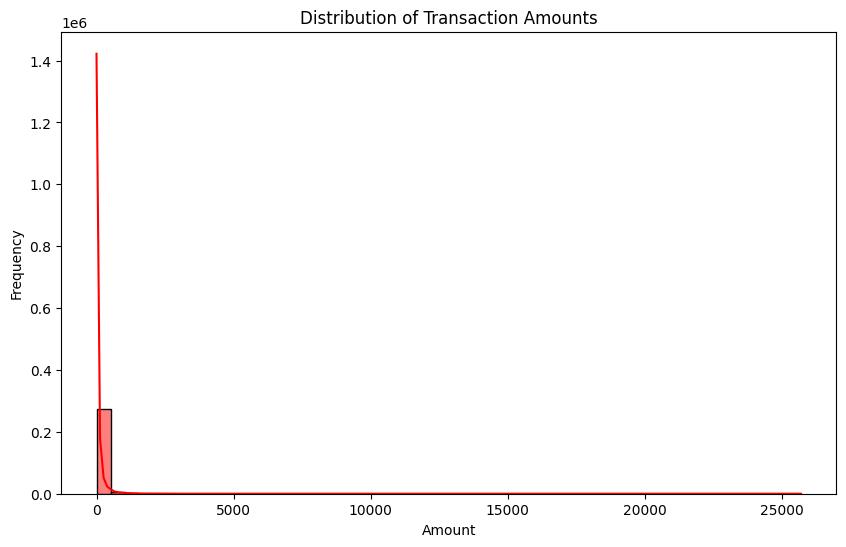

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(df1['Amount'], bins=50, kde=True, color='red')

plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

The transaction data follows a right-tailed distribution (right-skewed). While the vast majority of activity is concentrated in low-value daily purchases, the 'tail' extends far to the right, representing rare but significant high-value transactions that deviate from the norm.

## **Fraudulent Transaction Density Plot**

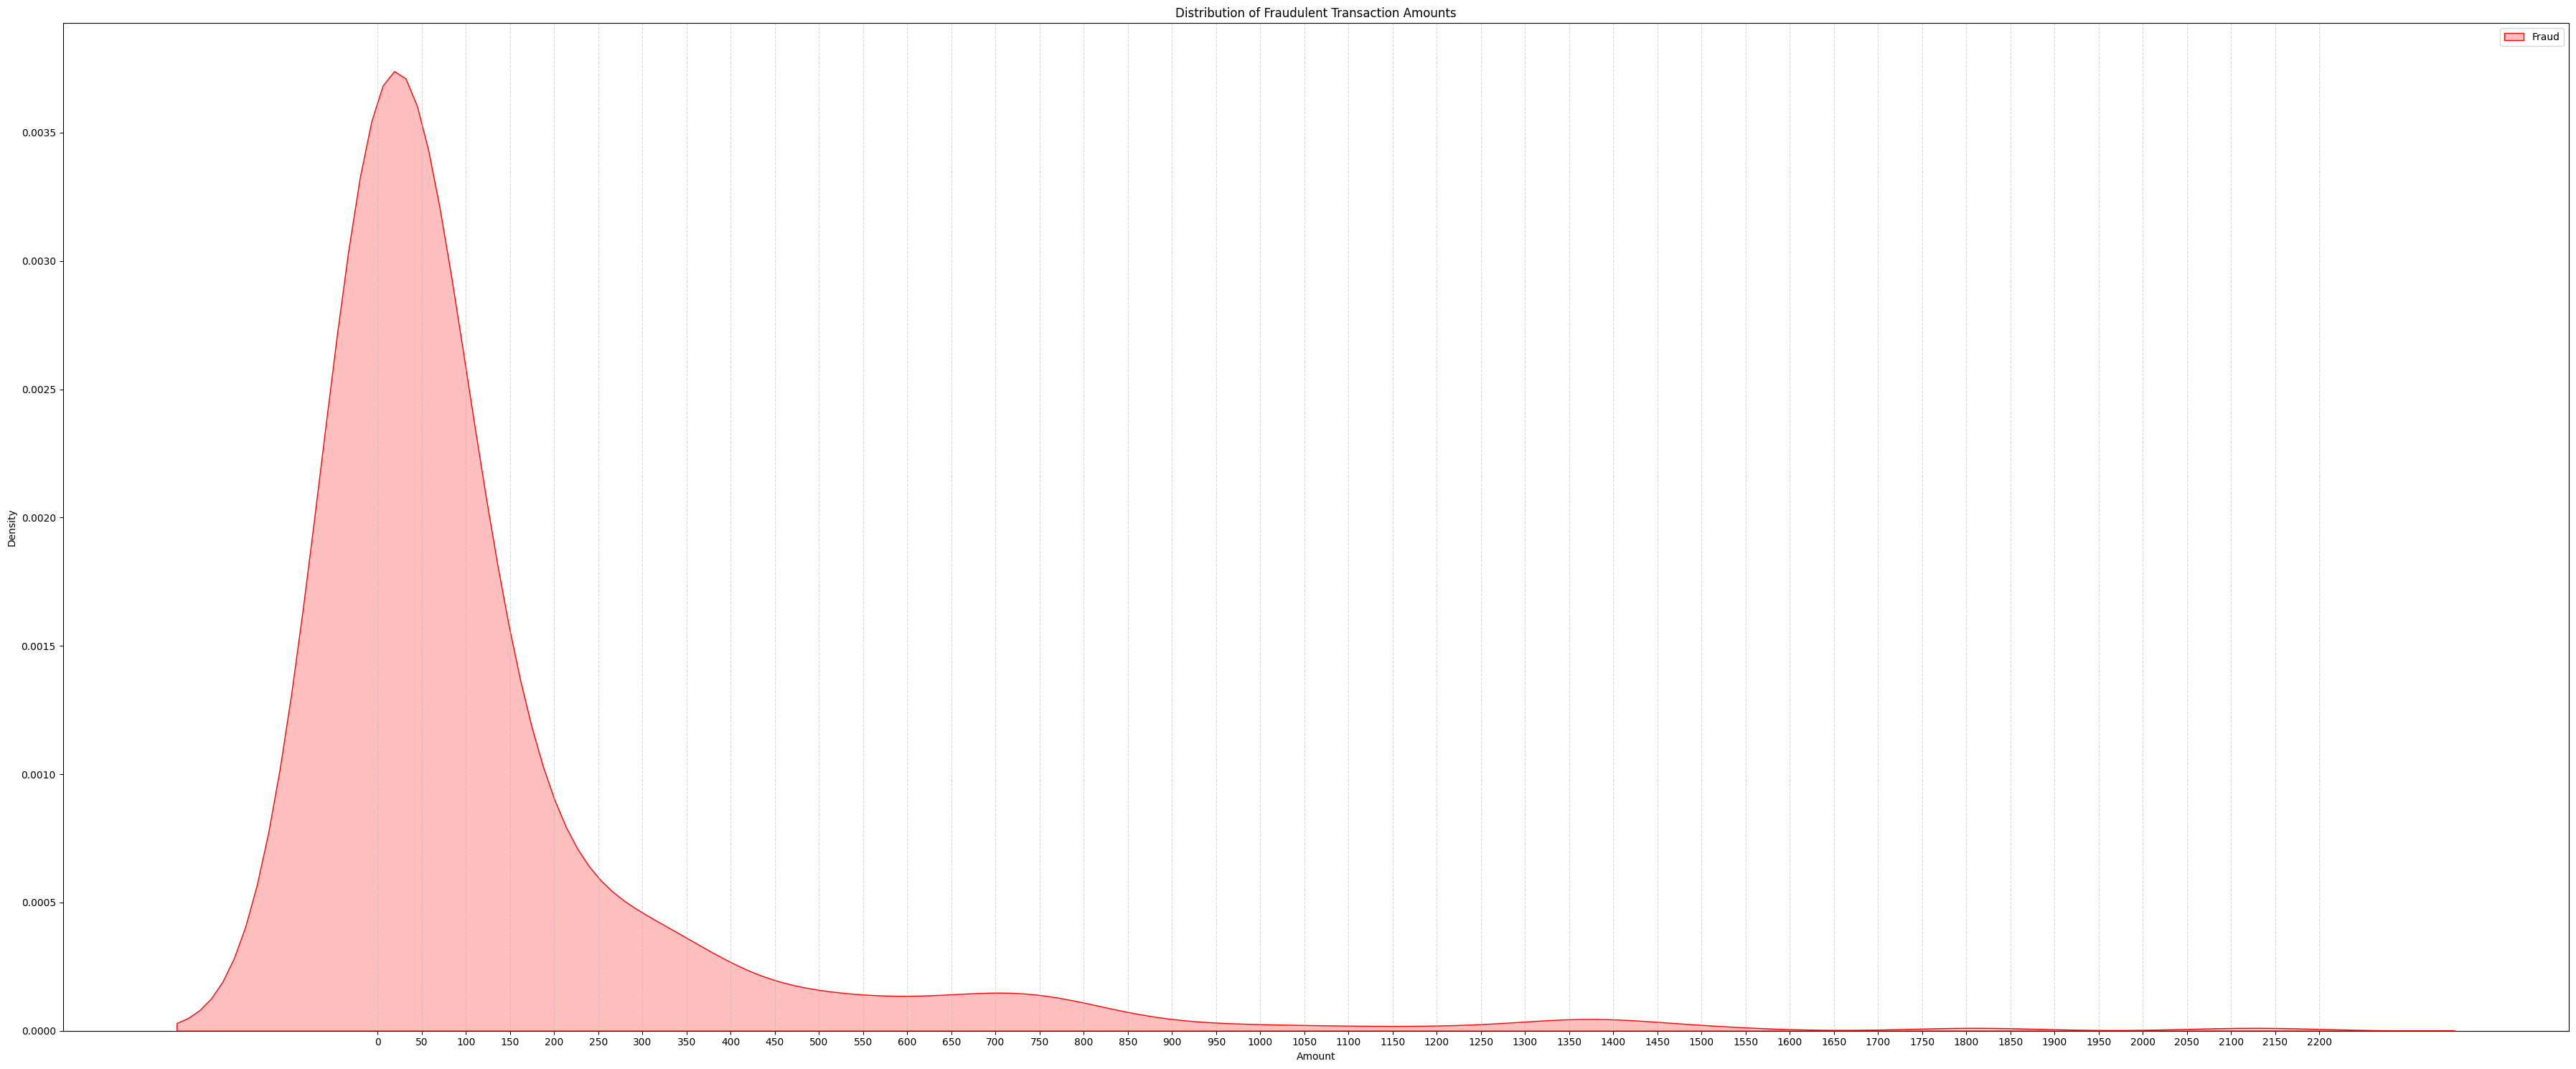

In [ ]:
import matplotlib.ticker as ticker

plt.figure (figsize=(36,15))
sns.kdeplot (df1[df1['Class']==1]['Amount'], label='Fraud', fill=True, color='red')

max_val = df1[df1['Class']==1]['Amount'].max()
plt.xticks (np.arange(0, max_val + 100, step=50))

plt.grid (True, axis='x', linestyle='--', alpha=0.5)

plt.title ("Distribution of Fraudulent Transaction Amounts")
plt.legend ()
plt.tight_layout ()
plt.show ()

**Most frauds between amount 15 and 25**

## **Transaction Time Distribution**

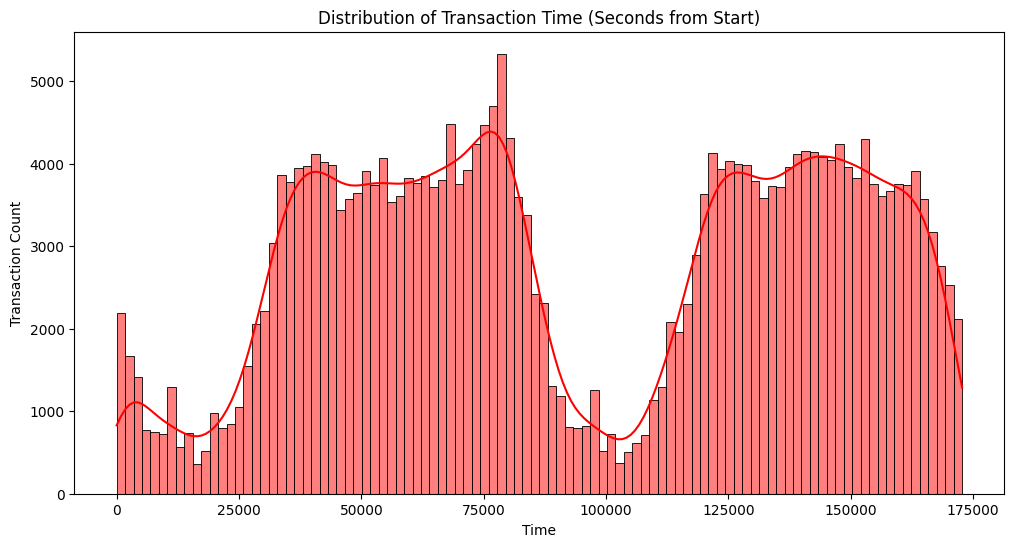

In [ ]:
plt.figure(figsize=(12, 6))


sns.histplot(df1['Time'], bins=100, kde=True, color='red')

plt.title('Distribution of Transaction Time (Seconds from Start)')
plt.xlabel('Time')
plt.ylabel('Transaction Count')

plt.show()

Transactions are distributed across the entire time period in the dataset. This indicates continuous transaction activity over time.

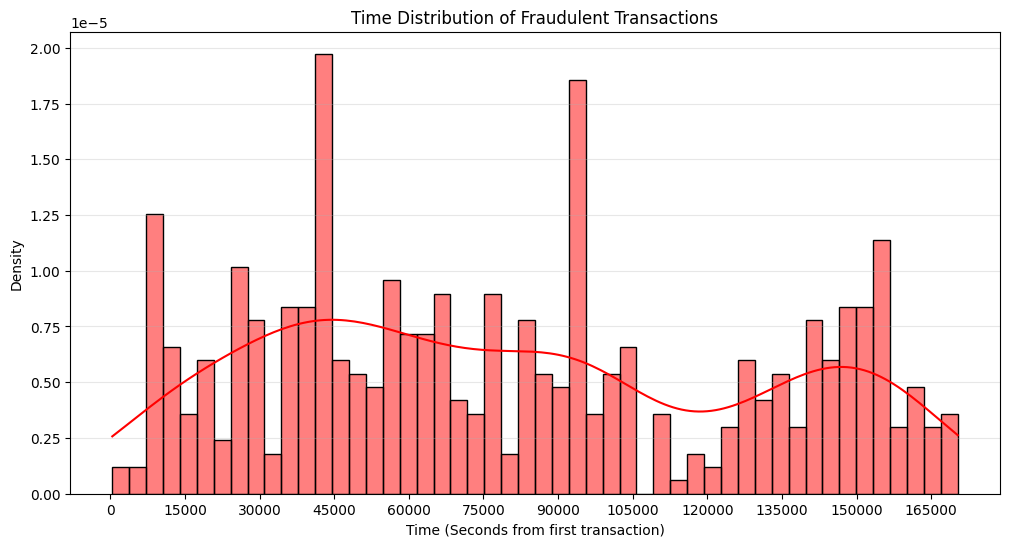

In [ ]:
fraud_data = df[df['Class'] == 1]

plt.figure(figsize=(12, 6))

sns.histplot(fraud_data['Time'], bins=50, kde=True, color='red', stat="density")

plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=15))

plt.title('Time Distribution of Fraudulent Transactions')
plt.xlabel('Time (Seconds from first transaction)')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.3)

plt.show()

We can now view when most fraud transactions happened, ie around 40000 - 45000 mark

## **Transaction amounts where most fraud happen**

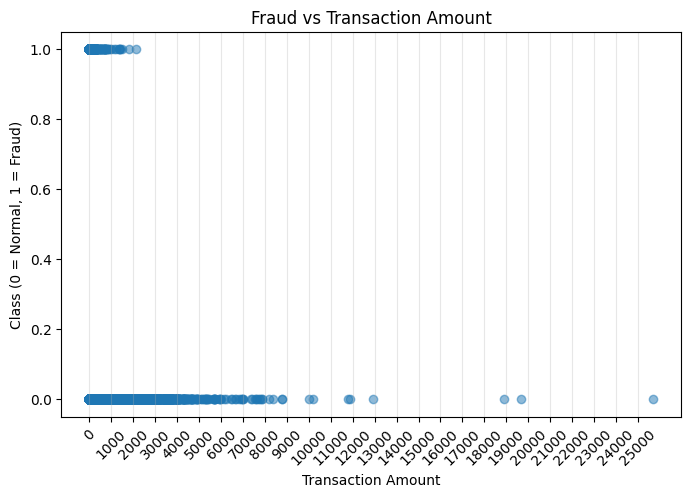

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df1['Amount'], df1['Class'], alpha=0.5)
max_amt = df1['Amount'].max()
plt.xticks(np.arange(0, max_amt, step=1000), rotation=45)

plt.grid(True, axis='x', alpha=0.3)

plt.title("Fraud vs Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Class (0 = Normal, 1 = Fraud)")

plt.show()

We see that most frauds happen where transaction amount are between 0 to 2500

## **Correlaton plot**

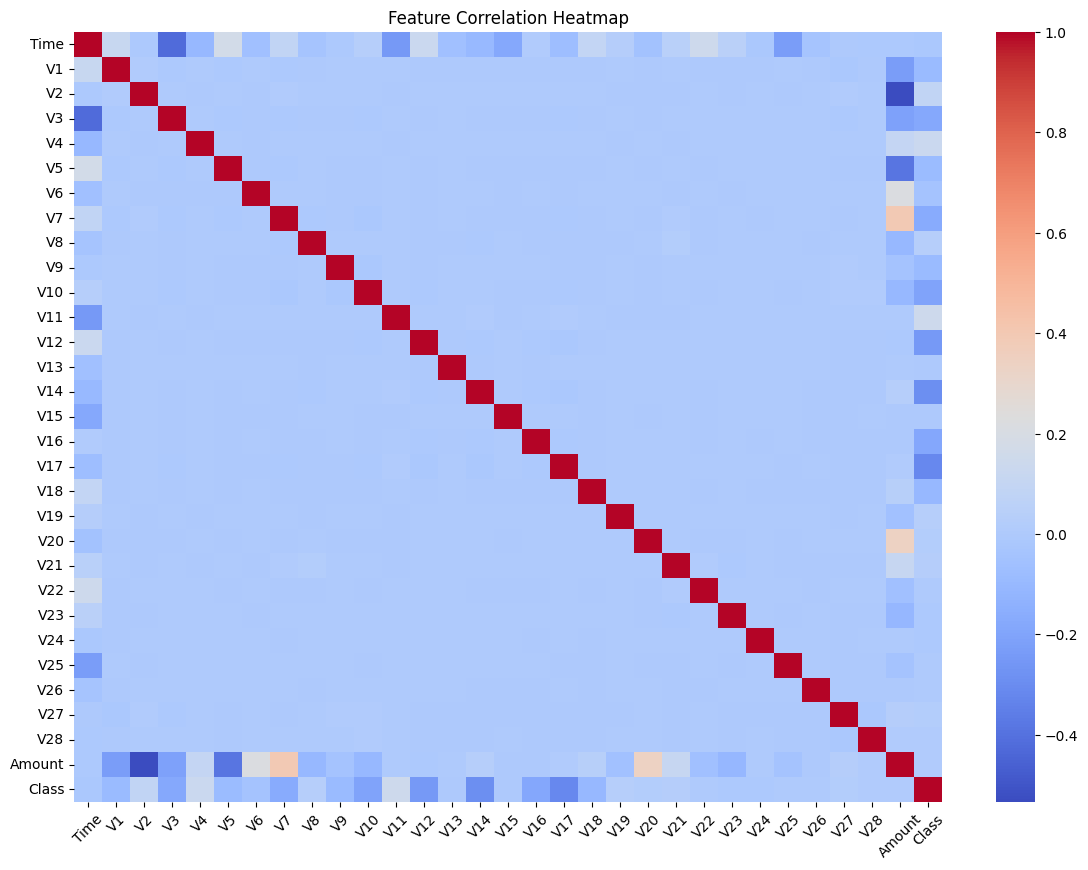

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(df1.corr(), cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

The heatmap shows the correlation between different features in the dataset. Most features have low correlation with each other because they are anonymized PCA transformed variables.

## **Outlier Detection**

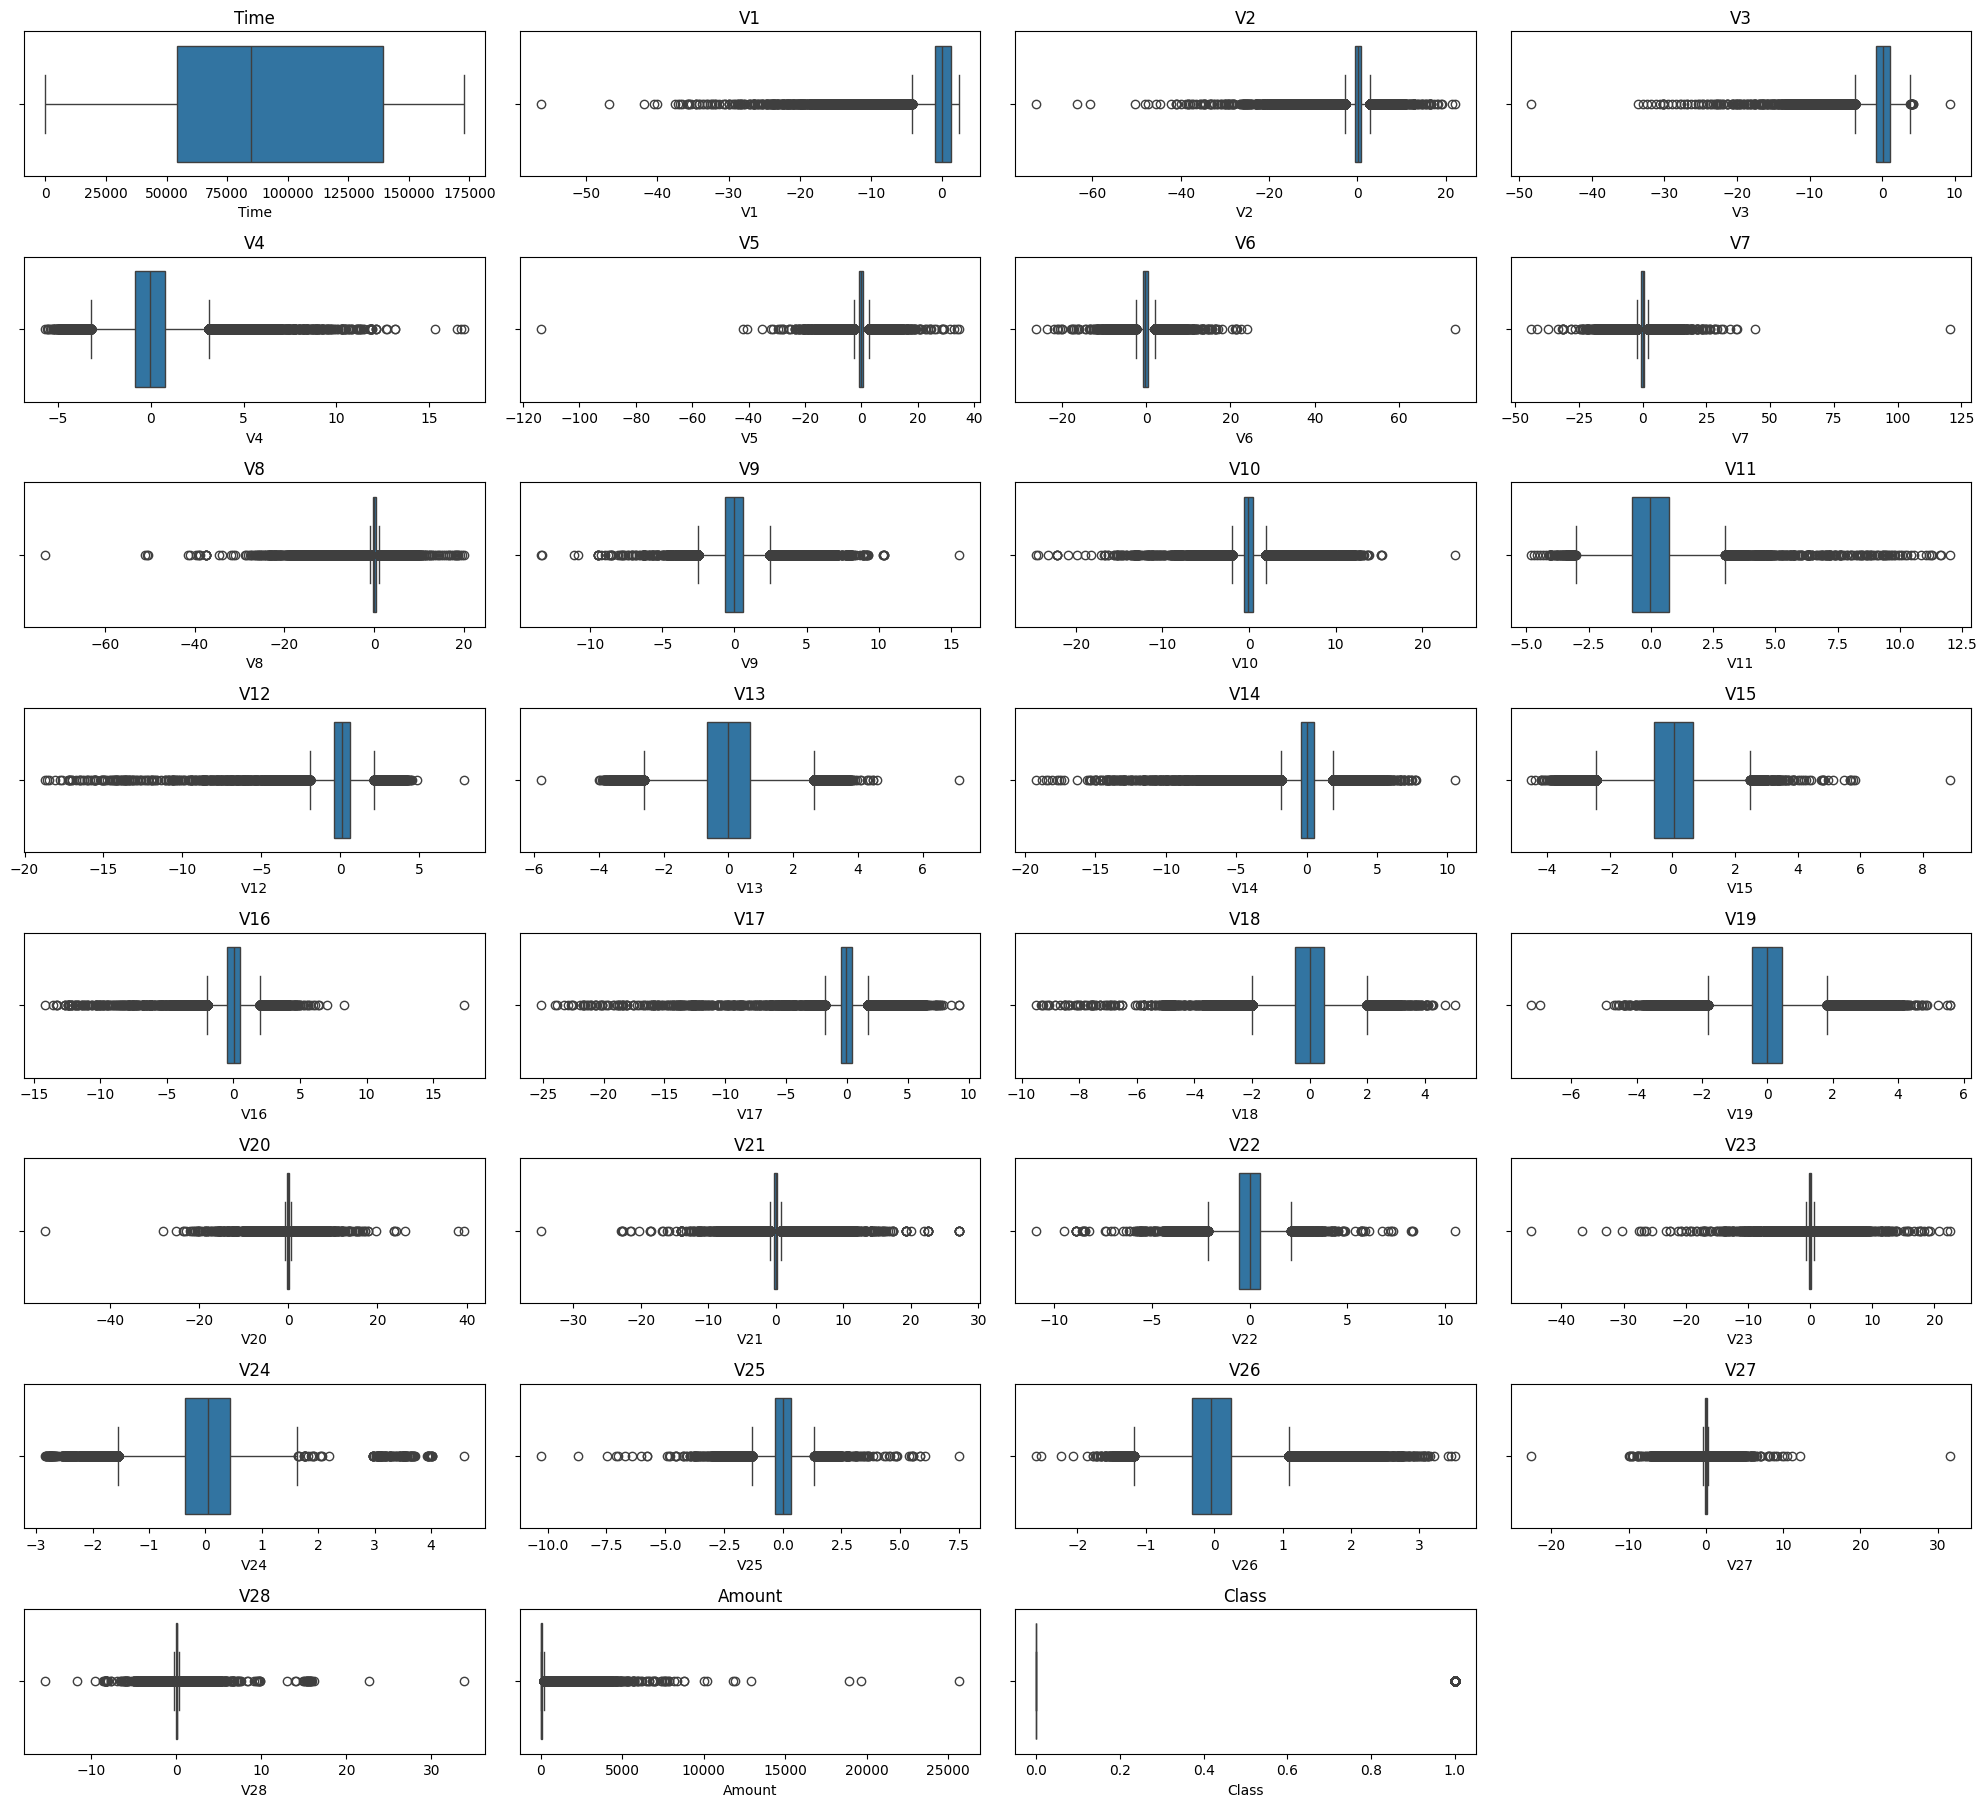

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = df1.columns

fig, axes = plt.subplots(9, 4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)


for j in range(i+1, 36):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
print (df1.skew() ,'\n\n')
print (df1.kurtosis())

Time      -0.035581
V1        -3.273271
V2        -4.695162
V3        -2.151984
V4         0.671504
V5        -2.414079
V6         1.829880
V7         2.890271
V8        -8.310970
V9         0.537663
V10        1.252967
V11        0.344074
V12       -2.199008
V13        0.064293
V14       -1.918804
V15       -0.309659
V16       -1.051161
V17       -3.690497
V18       -0.248661
V19        0.108312
V20       -2.043121
V21        2.820033
V22       -0.182330
V23       -5.867221
V24       -0.552129
V25       -0.415744
V26        0.580292
V27       -0.753804
V28       11.555115
Amount    16.978803
Class     24.430545
dtype: float64 


Time       -1.293432
V1         32.727332
V2         96.898173
V3         25.186530
V4          2.618780
V5        209.277467
V6         42.838886
V7        414.142188
V8        215.016933
V9          3.516661
V10        29.843899
V11         1.546849
V12        18.941584
V13         0.195840
V14        23.041488
V15         0.286407
V16         9.850013
V17  

Dataset has extreme outliers

Distributions are not normal at all


## **Feature Importance**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = df1.drop('Class', axis=1)
y = df1['Class']

model = RandomForestClassifier()
model.fit(X, y)

importances = model.feature_importances_

print (importances)

[0.01199622 0.01491412 0.01109823 0.01958476 0.03035747 0.0118749
 0.01632243 0.02767966 0.01294245 0.03826356 0.06933036 0.07349598
 0.1300434  0.0100232  0.11381387 0.01333388 0.0523723  0.16855798
 0.03827194 0.01210144 0.01256725 0.01811326 0.01197032 0.00689555
 0.01121989 0.008704   0.01941309 0.01178834 0.01222018 0.01072995]


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
17,V17,0.168558
12,V12,0.130043
14,V14,0.113814
11,V11,0.073496
10,V10,0.069330
16,V16,0.052372
18,V18,0.038272
9,V9,0.038264
4,V4,0.030357
7,V7,0.027680


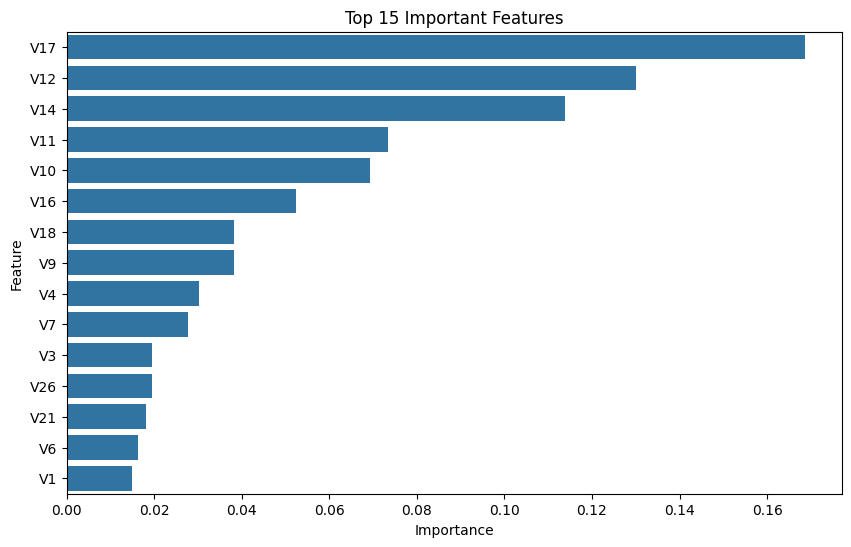

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title("Top 15 Important Features")
plt.show()

V17, V14, V12, V16 and V10 rank high in feature importance

## **EDA Summary & Key Insights**

1. The dataset consists of transactional records with both time-based and PCA-transformed features (V1–V28), along with the target variable Class.

2. There are no significant missing values, and duplicate records were handled appropriately.

3. The target variable is highly imbalanced, with fraudulent transactions forming a very small fraction of the dataset. This is evident from both count distribution and high skewness/kurtosis values.

4. Most features exhibit non-normal distributions, with significant skewness observed across several variables. Features such as Amount and V28 show extreme positive skewness, indicating the presence of large outliers.

5. Kurtosis values are very high for multiple features, confirming heavy-tailed distributions and extreme outliers, especially in transaction-related variables.

6. Correlation analysis indicates low linear correlation among most features, which is expected due to PCA transformation. However, some features show stronger relationships with the target variable.

7. Feature importance analysis using a Random Forest model highlights that only a subset of features significantly contribute to fraud detection, while many features have minimal predictive impact.

8. Most frauds occured for amounts between 15 and 25

## **Next Steps**

1. Apply feature scaling and transformation (e.g., log transformation for Amount) to handle skewness.

2. Address class imbalance using techniques such as SMOTE, undersampling, or class-weighted models.

3. Consider feature selection to reduce dimensionality and improve model efficiency.

4. Use robust evaluation metrics such as ROC-AUC, Precision-Recall, given the imbalance in the dataset.

5. Proceed with building classification models such as Logistic Regression, Random Forest, or Gradient Boosting.

## **Importing all needed libraries**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import StandardScaler

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df1.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## **Define features and target**

In [ ]:
X = df1.drop('Class' , axis = 1)
Y = df1['Class']

## **Train, Test, Split (Stratified)**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## **Define Models**

In [55]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=50),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50)
}

## **Cross Validation Setup**

In [56]:
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'roc_auc']

## **Pipeline + Loop**

In [57]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'ROC AUC': scores['test_roc_auc'].mean()
    })

results_df = pd.DataFrame(results).sort_values(by='ROC AUC', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,ROC AUC
3,Gradient Boosting,0.992422,0.164493,0.867725,0.976420
0,Logistic Regression,0.990938,0.152173,0.883598,0.969824
2,Random Forest,0.999511,0.880448,0.820106,0.963927
1,Decision Tree,0.998088,0.455128,0.751323,0.874911


## **Select Best Model**

In [66]:
best_model_name = results_df.iloc[0]['Model']
best_model_base = models[best_model_name]
print (best_model_name)

Gradient Boosting


But for a balanced Random Forest was chosen due to its high precision and balanced recall, making it more practical by reducing false positives while still detecting fraud effectively.

In [67]:
best_model_name = 'Random Forest'
best_model_base = models[best_model_name]
print (best_model_name)

Random Forest


## **Final Pipeline**

In [68]:
final_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', best_model_base)
])

final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=42)), ('scaler', StandardScaler()),
                ('model', RandomForestClassifier(n_estimators=50))])

## **Predictions**

In [69]:
y_pred = final_pipeline.predict(X_test)
y_prob = final_pipeline.predict_proba(X_test)[:,1]

## **Final Metrics**

In [70]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9994889507630493
Precision: 0.9230769230769231
Recall: 0.7578947368421053
ROC AUC: 0.937806830185559


## **Confusion Matrix**

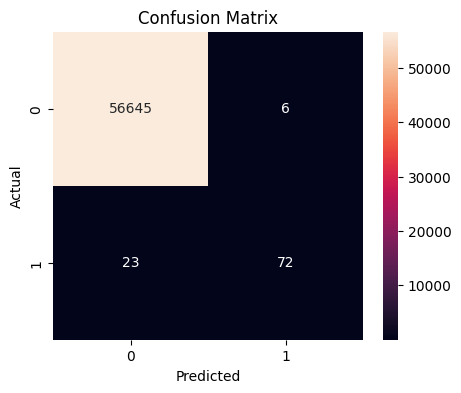

In [71]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **ROC Curve**

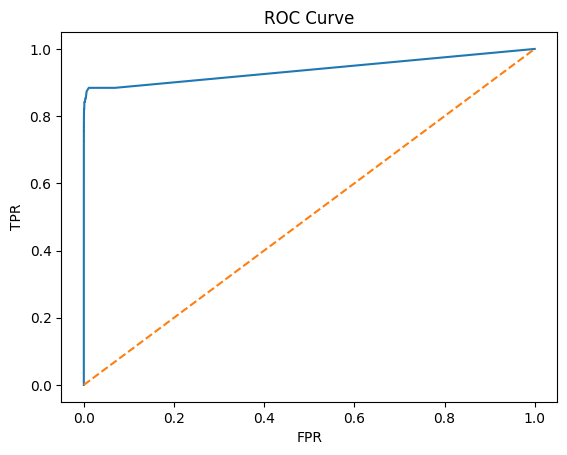

In [72]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

## **Actual vs Predicted**

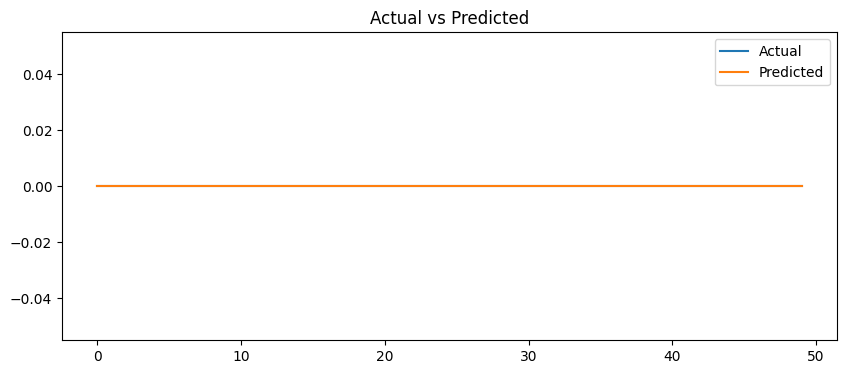

In [73]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

plt.figure(figsize=(10,4))
plt.plot(comparison['Actual'].values[:50], label='Actual')
plt.plot(comparison['Predicted'].values[:50], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

## **Feature Importance**

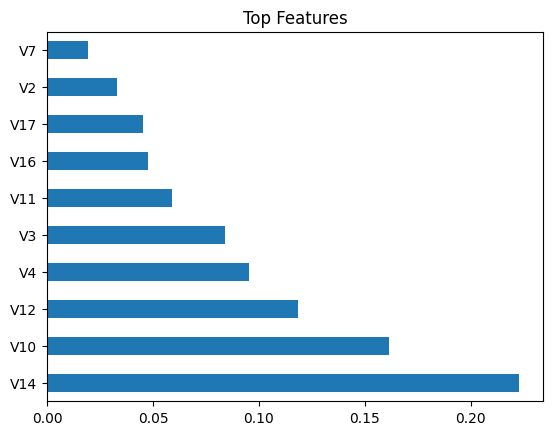

In [74]:
if hasattr(final_pipeline.named_steps['model'], 'feature_importances_'):
    importance = pd.Series(
        final_pipeline.named_steps['model'].feature_importances_,
        index=X.columns
    )
    importance.sort_values(ascending=False).head(10).plot(kind='barh')
    plt.title("Top Features")
    plt.show()

# **🔹 📊 Final ML Conclusion**
## **🧠 Model Evaluation Summary**

1. Multiple machine learning models were trained and evaluated using Stratified Cross-Validation to ensure robustness on an imbalanced dataset.

2. To address class imbalance, SMOTE was applied within the pipeline, preventing data leakage and ensuring reliable validation.

3. Performance was evaluated using Accuracy, Precision, Recall, and ROC-AUC, with a focus on Recall and ROC-AUC due to the fraud detection context.

## **🔍 Key Findings**

1. The dataset is highly imbalanced, making accuracy an unreliable metric for model evaluation.

2. Models such as Logistic Regression and Gradient Boosting achieved higher recall, indicating better fraud detection capability.

3. Random Forest demonstrated the best balance between precision and recall, significantly reducing false positives while maintaining strong detection performance.

4. ROC-AUC scores across models were consistently high, indicating strong separability between fraudulent and non-fraudulent transactions.

## **🏆 Final Model Selection**

Random Forest was selected as the final model due to its:
1. High precision (reducing false alarms)

2. Competitive recall (detecting fraud effectively)

3. Strong overall ROC-AUC performance

## **⚖️ Trade-off Consideration**

1. A key trade-off exists between precision and recall:

    i. Higher recall models detect more fraud but increase false positives.

    ii. Higher precision models reduce false alerts but may miss some fraud cases.

    iii. The chosen model provides an optimal balance suitable for real-world deployment.

## **🚀 Final Conclusion**

1. A robust, leakage-free ML pipeline was developed incorporating preprocessing, imbalance handling, and cross-validation.

2. The final model demonstrates strong performance in detecting fraudulent transactions while maintaining practical usability.

3. This approach ensures reliable and scalable fraud detection, aligning with real-world financial risk management requirements.